### ECON 452: Final Assignment
#### Lutein Lammens, Julia Miskiewicz, Tanishq Tiwari

### Question 1: Instrumental Variables
Building on the in-class discussion, we use demand and supply instruments to identify the structural model parameters.

##### 1. Demand: Explain (in theory) why BLP instruments can be used to estimate demand parameters taking price endogeneity into account.
Prices are endogenous in the BLP demand system because firms set prices using information about unobserved quality shocks, so price is correlated with the error term. BLP instruments use other products' observed characteristics to create exogenous variation in prices through competition and substitution, while remaining uncorrelated with product $j$'s unobserved demand shock. Therefore, they satisfy relevance and exclusion, which identifies the demand parameters through the GMM moment condition:
$$
E[Z_{jt}^D \xi_{jt}] = 0.
$$

##### 2. Demand: In this exercise, we use two sets of instruments. Building on the provided definitions, explain verbally how demand instruments0-demand instruments3 as well as supply instruments0-supply instruments5 in products pizza.csv are exactly constructed.

The BLP-style demand instruments are constructed from the exogenous demand characteristics, $rating_{jt}$ and $deliverytime_{jt}$, using sums over other products in the same market. In particular, `demand_instruments0` and `demand_instruments2` are sums over the firm's other products, while `demand_instruments1` and `demand_instruments3` are sums over rival firms' products. The instruments are built from the characteristics $rating$ and $deliverytime$ using the standard BLP same-firm and rival-firm sums.

`demand_instruments4` is $hourlywages_{jt}$, which acts as a cost shifter. This is a valid demand instrument because wages affect prices through marginal costs, but wages do not enter consumers' utility directly.

On the supply side, `supply_instruments0` and `supply_instruments1` are sums of $hourlywages$ over the firm's other products and rival products, respectively. The remaining supply instruments, `supply_instruments2` through `supply_instruments5`, are the same BLP sums based on $rating$ and $deliverytime$. These are valid supply instruments because $rating$, $deliverytime$, and $hourlywages$ enter the marginal cost equation and are assumed to be uncorrelated with the unobserved cost shock $\omega_{jt}$.

#### 3. . What shocks can be used as demand instruments and how do they relate to demand instruments4?
Demand instruments can come from cost shocks or cost shifters, because these affect equilibrium prices through marginal costs but do not enter consumer utility directly. In this assignment, $hourlywages_{jt}$ plays that role, since it appears in the marginal cost equation but not in the utility function. Therefore, `demand_instruments4` corresponds to the excluded cost shifter $hourlywages_{jt}$, which helps identify demand by shifting prices without directly shifting consumer utility.

### Question 2: Model Estimation

In [4]:
!pip install pyblp

In [5]:
# Import packages
import numpy as np
import pandas as pd
import pyblp

In [ ]:
# Load data
product_data = pd.read_csv("products_pizza.csv")
agent_data = pd.read_csv("agents_pizza.csv")

# Check
print(product_data.head())
print(agent_data.head())

   v1  market_ids  firm_ids    shares  demand_instruments0  \
0   0           0         0  0.006038             1.873110   
1   1           0         0  0.008047             2.242486   
2   2           0         0  0.004980             2.174373   
3   3           0         0  0.006846             2.471596   
4   4           0         0  0.011540             2.334877   

   demand_instruments1  demand_instruments2  demand_instruments3  \
0             9.154572             1.199421            10.333022   
1             9.154572             1.271857            10.333022   
2             9.154572             1.883209            10.333022   
3             9.154572             1.901145            10.333022   
4             9.154572             1.407037            10.333022   

   demand_instruments4  supply_instruments0  supply_instruments1  \
0             0.783960             2.284171             7.219228   
1             0.458989             2.609143             7.219228   
2             

##### For missing values in `deliverytime`, we impute them using the mean `deliverytime` within each market.

In [7]:
# Impute missing delivery times with market-level mean
product_data["deliverytime"] = product_data.groupby("market_ids")["deliverytime"].transform(lambda x: x.fillna(x.mean()))

# If any are still missing, use overall mean as backup
product_data["deliverytime"] = product_data["deliverytime"].fillna(
    product_data["deliverytime"].mean())

From the assignment, demand utility is given by
$$
u_{ijt} = \beta_i^p p_{jt} + \beta^d deliverytime_{jt} + \beta^r rating_{jt} + \xi_{jt} + \epsilon_{ijt},
$$
and marginal cost is given by
$$
mc_{jt} = \gamma_0 + \gamma_1 rating_{jt} + \gamma_3 hourlywages_{jt} + \gamma_4 deliverytime_{jt} + \omega_{jt}.
$$

Therefore, the natural `pyblp` setup is:
- $
X_1 = (prices, deliverytime, rating),
$
which contains the linear demand characteristics,

- $
X_2 = (1, prices),
$
which contains the nonlinear demand characteristics, and

- $
X_3 = (1, rating, hourlywages, deliverytime),
$
which contains the supply-side marginal cost characteristics.

In [8]:
# Linear demand characteristics
X1_formulation = pyblp.Formulation('0 + prices + deliverytime + rating')

# Nonlinear demand characteristics
# Random coefficient on constant, and price interacted with demographics
X2_formulation = pyblp.Formulation('1 + prices')

# Supply-side marginal cost characteristics
X3_formulation = pyblp.Formulation('1 + rating + hourlywages + deliverytime')

product_formulations = (X1_formulation, X2_formulation, X3_formulation)

The assignment says the only demographic shifter is inverse income, and it shifts the price coefficient. So, the agent formulation should use `invincome`. Also, there is no demographic shifter for the constant term.

In [9]:
agent_formulation = pyblp.Formulation('0 + invincome')

Since
$$
X_2 = (1, prices),
$$
there are two nonlinear demand characteristics. Therefore, the matrix
$$
\Sigma
$$
has dimension $2 \times 2$. Because there is one demographic variable, $invincome$, the matrix
$$
\Pi
$$
has dimension $2 \times 1$.

There is no random coefficient on price, so the row and column of $\Sigma$ corresponding to $price$ are set to zero. In addition, there is no demographic shifter on the constant term, so the corresponding element of $\Pi$ is set to zero.

In [10]:
# Starting values for nonlinear parameters
initial_sigma = np.array([
    [1.0, 0.0],   # random coefficient on constant
    [0.0, 0.0]    # no random coefficient on price
])

initial_pi = np.array([
    [0.0],        # no demographic shifter on constant
    [-1.0]        # invincome shifts price sensitivity
])

For the linear parameters, we use economically sensible starting values: a negative coefficient on price, a negative coefficient on delivery time, a positive coefficient on rating, and positive marginal cost coefficients on rating, hourly wages, and delivery time.

In [11]:
# Starting values for linear demand parameters: prices, deliverytime, rating
initial_beta = np.array([
    [-1.0],   # prices
    [-1.0],   # deliverytime
    [ 1.0]    # rating
])

# Starting values for supply parameters: constant, rating, hourlywages, deliverytime
initial_gamma = np.array([
    [1.0],    # constant
    [0.5],    # rating
    [0.5],    # hourlywages
    [0.5]     # deliverytime
])

In [12]:
# Build and solve the problem
problem = pyblp.Problem(
    product_formulations,
    product_data,
    agent_formulation,
    agent_data
)

print(problem)

Initializing the problem ...
Initialized the problem after 00:00:00.

Dimensions:
 T    N    F     I     K1    K2    K3    D    MD    MS 
---  ---  ---  -----  ----  ----  ----  ---  ----  ----
20   500   6   20000   3     2     4     1    7     10 

Formulations:
        Column Indices:              0           1             2            3      
-------------------------------  ---------  ------------  -----------  ------------
  X1: Linear Characteristics      prices    deliverytime    rating                 
 X2: Nonlinear Characteristics       1         prices                              
X3: Linear Cost Characteristics      1         rating     hourlywages  deliverytime
        d: Demographics          invincome                                         
Dimensions:
 T    N    F     I     K1    K2    K3    D    MD    MS 
---  ---  ---  -----  ----  ----  ----  ---  ----  ----
20   500   6   20000   3     2     4     1    7     10 

Formulations:
        Column Indices:             

In [13]:
results = problem.solve(
    sigma=initial_sigma,
    pi=initial_pi,
    beta=initial_beta,
    gamma=initial_gamma
)

print(results)

Solving the problem ...

Nonlinear Coefficient Initial Values:
Sigma:        1           prices      |   Pi:      invincome  
------  -------------  -------------  |  ------  -------------
  1     +1.000000E+00                 |    1     +0.000000E+00
prices  +0.000000E+00  +0.000000E+00  |  prices  -1.000000E+00

Beta Initial Values:
   prices      deliverytime      rating    
-------------  -------------  -------------
-1.000000E+00  -1.000000E+00  +1.000000E+00

Gamma Initial Values:
      1           rating       hourlywages   deliverytime 
-------------  -------------  -------------  -------------
+1.000000E+00  +5.000000E-01  +5.000000E-01  +5.000000E-01

Nonlinear Coefficient Lower Bounds:
Sigma:        1           prices      |   Pi:      invincome  
------  -------------  -------------  |  ------  -------------
  1     +0.000000E+00                 |    1     +0.000000E+00
prices  +0.000000E+00  +0.000000E+00  |  prices      -INF     

Beta Lower Bounds:
   prices      deliver

We also experimented with an alternative optimization routine, `l-bfgs-b`, to check whether the estimates were sensitive to the optimizer.

In [14]:
optimizer = pyblp.Optimization('l-bfgs-b', {'gtol': 1e-4})

results = problem.solve(
    sigma=initial_sigma,
    pi=initial_pi,
    beta=initial_beta,
    gamma=initial_gamma,
    optimization=optimizer
)

Solving the problem ...

Nonlinear Coefficient Initial Values:
Sigma:        1           prices      |   Pi:      invincome  
------  -------------  -------------  |  ------  -------------
  1     +1.000000E+00                 |    1     +0.000000E+00
prices  +0.000000E+00  +0.000000E+00  |  prices  -1.000000E+00

Beta Initial Values:
   prices      deliverytime      rating    
-------------  -------------  -------------
-1.000000E+00  -1.000000E+00  +1.000000E+00

Gamma Initial Values:
      1           rating       hourlywages   deliverytime 
-------------  -------------  -------------  -------------
+1.000000E+00  +5.000000E-01  +5.000000E-01  +5.000000E-01

Nonlinear Coefficient Lower Bounds:
Sigma:        1           prices      |   Pi:      invincome  
------  -------------  -------------  |  ------  -------------
  1     +0.000000E+00                 |    1     +0.000000E+00
prices  +0.000000E+00  +0.000000E+00  |  prices      -INF     

Beta Lower Bounds:
   prices      deliver

In [15]:
# Print results
print("Beta estimates:")
print(results.beta)

print("Gamma estimates:")
print(results.gamma)

print("Sigma estimates:")
print(results.sigma)

print("Pi estimates:")
print(results.pi)

Beta estimates:
[[-0.01453219]
 [-0.86226486]
 [ 0.91549728]]
Gamma estimates:
[[ 0.68420385]
 [ 0.48790099]
 [ 1.40335411]
 [-0.71730705]]
Sigma estimates:
[[0.13984514 0.        ]
 [0.         0.        ]]
Pi estimates:
[[ 0.        ]
 [-4.13018554]]


#### Discuss the parameter estimates:
- **Price ($\beta^{p}$):** The estimated price coefficient is negative ($-0.0145$), which means that an increase in price lowers consumer utility and makes a pizza less likely to be chosen.

- **Delivery time ($\beta^{d}$):** The estimated delivery time coefficient is negative ($-0.8623$), which means that longer delivery times reduce consumer utility and demand.

- **Rating ($\beta^{r}$):** The estimated rating coefficient is positive ($0.9155$), which means that consumers prefer higher-rated pizzas.

- **Constant in marginal cost ($\gamma_{0}$):** The estimated constant term is positive ($0.6842$), which captures the baseline level of marginal cost.

- **Rating in marginal cost ($\gamma_{1}$):** The estimated coefficient on rating is positive ($0.4879$), suggesting that higher-rated pizzas are more costly to produce or provide.

- **Hourly wages in marginal cost ($\gamma_{3}$):** The estimated coefficient on hourly wages is positive ($1.4033$), which means that higher labor costs raise marginal cost.

- **Delivery time in marginal cost ($\gamma_{4}$):** The estimated coefficient on delivery time is negative ($-0.7173$), suggesting that pizzas with longer delivery times may have lower marginal costs.

- **$\Sigma$:** The estimated nonlinear coefficient on the constant is positive ($0.1401$), which implies heterogeneity in consumers’ baseline tastes for pizzas.

- **$\Pi$:** The estimated coefficient on the interaction between price and inverse income is negative ($-4.1302$), which means that lower-income consumers are more price sensitive.



**Note:** Although the estimates have economically sensible signs, the optimization did not fully converge, so they should be interpreted with caution.

### Question 3: Elasticities and Diversion Ratios

We use market 1 as the example market for this question.

In [16]:
# Compute elasticities and diversion ratios
elasticities = results.compute_elasticities()
diversions = results.compute_diversion_ratios()

Computing elasticities with respect to prices ...
Finished after 00:00:00.

Computing diversion ratios with respect to prices ...
Finished after 00:00:00.



In [17]:
# Pick example market
example_market = 1
single_market = product_data["market_ids"] == example_market

In [18]:
# Extract matrices for market 1
E = elasticities[single_market]
D = diversions[single_market]

print("Example market:", example_market)
print("Elasticity matrix shape:", E.shape)
print("Diversion matrix shape:", D.shape)

Example market: 1
Elasticity matrix shape: (25, 25)
Diversion matrix shape: (25, 25)


In [19]:
# Own- and cross-price elasticities
own_elasticities = np.diag(E)
cross_elasticities = E[~np.eye(E.shape[0], dtype=bool)]

print("Average own-price elasticity:", own_elasticities.mean())
print("Average cross-price elasticity:", cross_elasticities.mean())
print("Min own-price elasticity:", own_elasticities.min())
print("Max own-price elasticity:", own_elasticities.max())

Average own-price elasticity: -2.2530951952615217
Average cross-price elasticity: 0.05230913461100627
Min own-price elasticity: -2.4560605872276198
Max own-price elasticity: -1.9719969713789889


In [20]:
# Diversion ratios
outside_diversion = np.diag(D)
inside_diversion = D[~np.eye(D.shape[0], dtype=bool)]

print("Average diversion to outside good:", outside_diversion.mean())
print("Average diversion to inside goods:", inside_diversion.mean())
print("Max diversion to another inside product:", inside_diversion.max())

Average diversion to outside good: 0.3051488870574272
Average diversion to inside goods: 0.028952129705940532
Max diversion to another inside product: 0.09854289013190085


- **Own-price elasticity:** For market 1, the average own-price elasticity is $-2.2531$, which means that a 1\% increase in a pizza's own price lowers its demand by about 2.25\% on average.

- **Cross-price elasticity:** For market 1, the average cross-price elasticity is $0.0523$, which means that a 1\% increase in one pizza's price raises demand for other pizzas by about 0.05\% on average.

- **Diversion to the outside good:** For market 1, the average diversion to the outside good is $0.3051$, which means that about 30.5\% of lost demand goes to the outside option on average.

- **Diversion to inside goods:** For market 1, the average diversion to inside goods is $0.0290$, which means that about 2.9\% of lost demand is diverted to another pizza on average.

- **Maximum diversion to another inside product:** For market 1, the maximum diversion ratio to another inside product is $0.0985$, which means that the closest substitute captures about 9.85\% of the lost demand.

### Question 4: Marginal Costs, Markups, HHI, Consumer Surplus, and Profits

#### 1. Construct and summarize the distribution of marginal costs across products. Interpret the magnitude of the average marginal cost estimate.

In [21]:
import matplotlib.pyplot as plt

Computing marginal costs ...
Finished after 00:00:00.

Marginal costs across products
count    500.000000
mean       1.830081
std        0.585280
min        0.229519
25%        1.430099
50%        1.850248
75%        2.256078
max        3.184369
dtype: float64


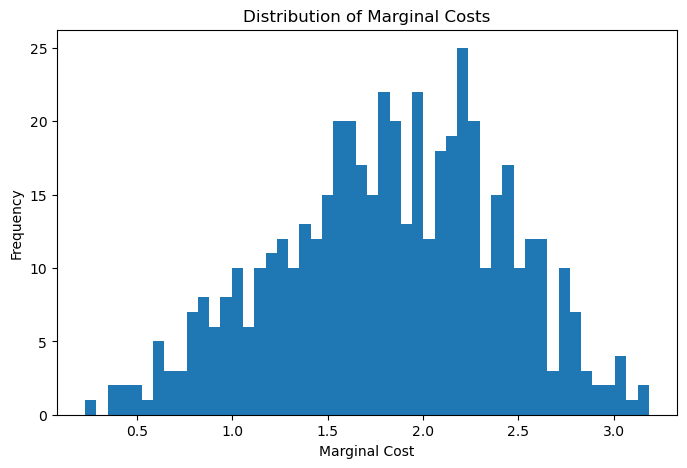

In [22]:
market_size = 100_000
slices_per_pizza = 6

costs = results.compute_costs()

print("Marginal costs across products")
print(pd.Series(costs.flatten()).describe())

plt.figure(figsize=(8, 5))
plt.hist(costs, bins=50)
plt.title("Distribution of Marginal Costs")
plt.xlabel("Marginal Cost")
plt.ylabel("Frequency")
plt.show()

**Interpretation:** The estimated magnitude of marginal costs is economically reasonable with the average marginal cost of about 1.83 dollars and a median of 1.85. The costs are roughly similar across firms, with most restaurants incurring costs between 1.4 and 2.3 dollars per slice with s.d. of approximately 0.59 indicating small dispersion.

#### 2. Construct and summarize the distribution of markups across products. Interpret the magnitude of the average markup estimate. Using the Lerner index, related the estimated average markup to the average price elasticity derived above.

Computing markups ...
Finished after 00:00:00.


Markups summary:
count    500.000000
mean       0.470602
std        0.044244
min        0.377691
25%        0.441148
50%        0.462567
75%        0.491472
max        0.706299
dtype: float64


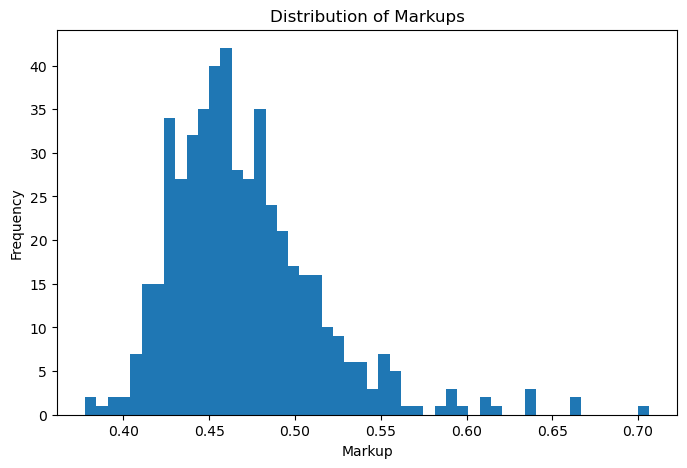

In [23]:
markups = results.compute_markups(costs=costs)

print("\nMarkups summary:")
print(pd.Series(markups.flatten()).describe())

plt.figure(figsize=(8, 5))
plt.hist(markups, bins=50)
plt.title("Distribution of Markups")
plt.xlabel("Markup")
plt.ylabel("Frequency")
plt.show()

In [24]:
# Lerner index
avg_own_elasticity = own_elasticities.mean()
implied_lerner = -1 / avg_own_elasticity

print("\nAverage price elasticity:", avg_own_elasticity)
print("Average markup:", markups.mean())
print("Lerner index from average elasticity (-1/epsilon):", implied_lerner)



Average price elasticity: -2.2530951952615217
Average markup: 0.4706021010941093
Lerner index from average elasticity (-1/epsilon): 0.44383388775720495


**Interpretation:** Average markup estimate is about 47%, meaning that prices are roughly 47% above marginal cost on average, with the majority being approximately between 44% and 50%. While these numbers signal substantial market power for the firms, they are not outstandingly high or low. After computing the Lerner index, we obtained approximately 0.44, which is very close to the estimated markup and signals coherence between the demand elasticities and the pricing equation. Overall, the markups suggest moderate competition, where demand is elastic and consumers will switch to competitors if the price is too high; however, it is not nearly perfectly elastic, which allows firms to set prices above marginal cost.

#### 3. Construct and summarize the distribution of the Herfindahl-Hirschman index (HHI) across markets. Is any of the markets highly concentrated (HHI≥2,500)?


Computing HHI ...
Finished after 00:00:00.


HHI summary:
count      20.000000
mean     1823.348699
std       140.186253
min      1677.246362
25%      1712.707151
50%      1795.216258
75%      1886.604176
max      2266.968603
dtype: float64


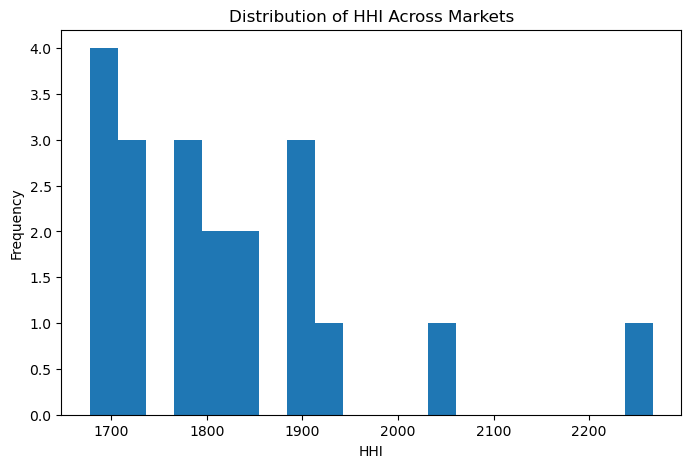

In [25]:
hhi = results.compute_hhi()

print("\nHHI summary:")
print(pd.Series(hhi.flatten()).describe())

plt.figure(figsize=(8, 5))
plt.hist(hhi, bins=20)
plt.title("Distribution of HHI Across Markets")
plt.xlabel("HHI")
plt.ylabel("Frequency")
plt.show()

In [26]:
highly_concentrated = (hhi >= 2500).sum()
print("Number of HHI >= 2500:", int(highly_concentrated))

Number of HHI >= 2500: 0


**Interpretation:** The average HHI across markets is about 1823 suggesting that on average markets are moderately concentrated. The maximum HHI is approximately 2267, which is below the 2500 threshold, therefore, none of the markets are highly concetrated.

#### 4. Construct and summarize the distribution of profits (across products) assuming a full pizza has 6 slices and there in total 100 thousand consumers in the market for pizzas. What’s the average profit per product?


Computing profits ...
Finished after 00:00:00.


Profits summary:
count      500.000000
mean     11976.033000
std       5542.703530
min       1941.268049
25%       7896.606062
50%      10999.074922
75%      14827.729498
max      32157.496374
dtype: float64
Average profit per product: 11976.032999762183


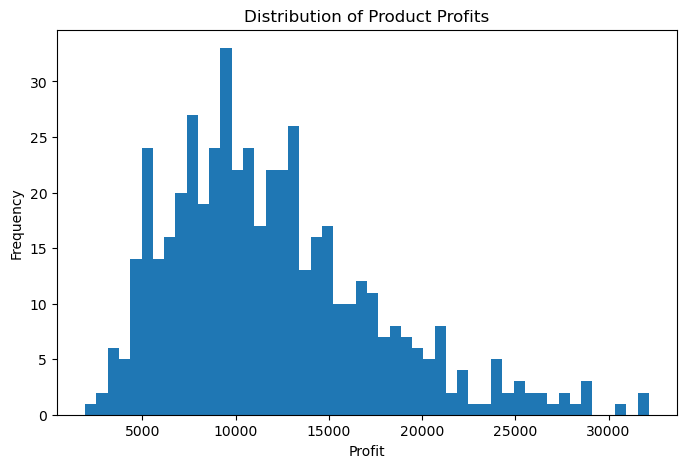

In [27]:
profits = results.compute_profits(costs=costs) * market_size * slices_per_pizza

print("\nProfits summary:")
print(pd.Series(profits.flatten()).describe())
print("Average profit per product:", profits.mean())

plt.figure(figsize=(8, 5))
plt.hist(profits, bins=50)
plt.title("Distribution of Product Profits")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

**Interpretation:** The average profit per product is approximately $11,976, with most product profits ranging between $7,896-14,827. The dispersion is quite large (s.d. = $5,542) which suggests reflects differences in market shares, marginal costs and prices.

#### 5. Construct and summarize the distribution of consumer surplus (across markets) a full pizza has 6 slices and there in total 100 thousand consumers in the market for pizzas. What’s the average consumer surplus per market?

Computing consumer surpluses with the equation that assumes away nonlinear income effects ...
Finished after 00:00:00.


Consumer surplus summary across markets:
count    2.000000e+01
mean     2.235894e+06
std      2.971517e+05
min      1.808998e+06
25%      2.014291e+06
50%      2.208263e+06
75%      2.404850e+06
max      2.836726e+06
dtype: float64
Average consumer surplus per market: 2235893.9608025597


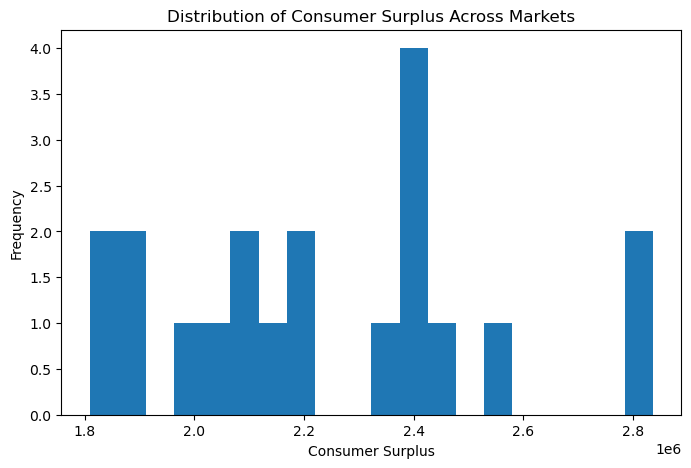

In [28]:
cs = results.compute_consumer_surpluses() * market_size * slices_per_pizza

print("\nConsumer surplus summary across markets:")
print(pd.Series(cs.flatten()).describe())
print("Average consumer surplus per market:", cs.mean())

plt.figure(figsize=(8, 5))
plt.hist(cs, bins=20)
plt.title("Distribution of Consumer Surplus Across Markets")
plt.xlabel("Consumer Surplus")
plt.ylabel("Frequency")
plt.show()

**Interpretation:** The average consumer surplus per market is about $2.24 million. All values span between from $1.8 million to $2.8 million across markets. High consumer surplus suggests that consumers benefit from markets offering differentiated products and that their willingness to pay exceeds the price they pay.

### Question 5: Merger Analysis: Now suppose that Fresh Brothers (firm id 1) acquires Italian Express Pizza (firm id 0), Lamonica’s NY Pizza (firm id 2), and Enzo’s Pizzeria (firm id 3).
#### 1. Construct the new equilibrium prices and market shares. Summarize the distribution of changes in the HHI across markets.

In [29]:
# merging firms and changing their ids to 1
product_data["merger_ids"] = product_data["firm_ids"].replace({
    0: 1,
    2: 1,
    3: 1
})


In [30]:
# new prices and market shares after merger
changed_prices = results.compute_prices(
    firm_ids=product_data["merger_ids"],
    costs=costs
)

changed_shares = results.compute_shares(changed_prices)

Solving for equilibrium prices ...
Finished after 00:00:01.

Computing shares ...
Finished after 00:00:00.



In [31]:
# Store product-level changes
merger_results = product_data.copy()
merger_results["pre_price"] = product_data["prices"]
merger_results["post_price"] = changed_prices
merger_results["delta_price"] = merger_results["post_price"] - merger_results["pre_price"]

merger_results["pre_share"] = product_data["shares"]
merger_results["post_share"] = changed_shares
merger_results["delta_share"] = merger_results["post_share"] - merger_results["pre_share"]

print("Price changes summary:")
print(merger_results["delta_price"].describe())

print("\nShare changes summary:")
print(merger_results["delta_share"].describe())

Price changes summary:
count    500.000000
mean       1.540081
std        2.272581
min       -1.271275
25%        0.163928
50%        0.990379
75%        1.987387
max       20.840273
Name: delta_price, dtype: float64

Share changes summary:
count    500.000000
mean      -0.002773
std        0.005249
min       -0.017363
25%       -0.006265
50%       -0.003380
75%        0.002426
max        0.009131
Name: delta_share, dtype: float64


Computing HHI ...
Finished after 00:00:00.


HHI changes summary across markets:
count      20.000000
mean     2046.360313
std       298.190638
min      1432.384696
25%      1874.452717
50%      1990.527664
75%      2223.252252
max      2651.028406
dtype: float64


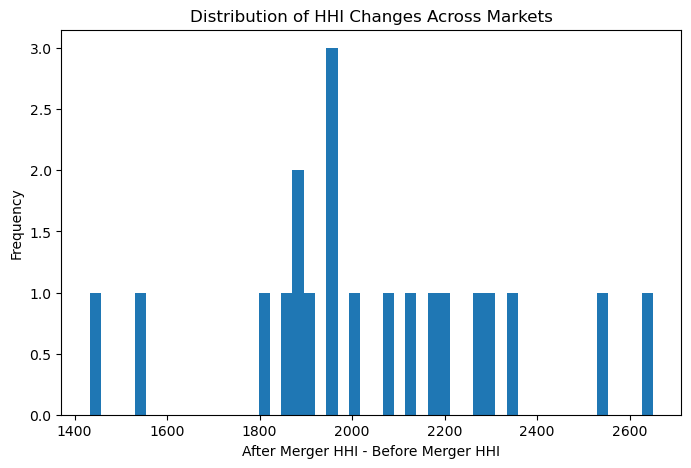

In [32]:
# HHI changes across markets
changed_hhi = results.compute_hhi(
    firm_ids=product_data["merger_ids"],
    shares=changed_shares
)

hhi_changes = (changed_hhi - hhi).flatten()

print("\nHHI changes summary across markets:")
print(pd.Series(hhi_changes).describe())

plt.figure(figsize=(8, 5))
plt.hist(hhi_changes, bins=50)
plt.title("Distribution of HHI Changes Across Markets")
plt.xlabel("After Merger HHI - Before Merger HHI")
plt.ylabel("Frequency")

plt.show()


**Interpretation:** The average change in HHI is about 2046. HHI increased for all firms as expected due to the merger of firms which made the market shares more concentrated and reduced the number of competitors. All marketd experienced notable positive HHI changes ranging from about 1432 to 2651.

#### 2. Construct and summarize the changes in markups across products. By how much do markups increase or decrease on average and why are they increasing/decreasing?

Computing markups ...
Finished after 00:00:00.


Markup changes summary across products:
count    500.000000
mean       0.123805
std        0.088078
min       -0.080045
25%        0.035740
50%        0.144958
75%        0.178394
max        0.403536
dtype: float64


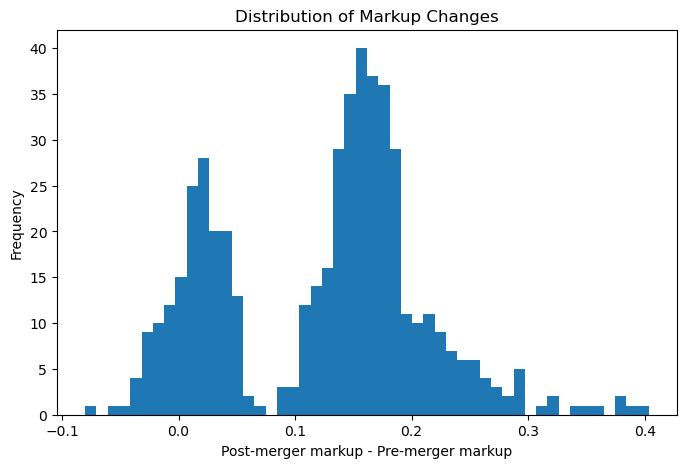

In [33]:
changed_markups = results.compute_markups(changed_prices, costs)

markup_changes = (changed_markups - markups).flatten()

print("\nMarkup changes summary across products:")
print(pd.Series(markup_changes).describe())

merged_firm = product_data["merger_ids"] == 1
non_merged_firm = product_data["merger_ids"] != 1

plt.figure(figsize=(8, 5))
plt.hist(markup_changes, bins=50)
plt.title("Distribution of Markup Changes")
plt.xlabel("Post-merger markup - Pre-merger markup")
plt.ylabel("Frequency")
plt.show()


Markup changes for merged firm's products:
count    340.000000
mean       0.175596
std        0.052068
min        0.042070
25%        0.143824
50%        0.165991
75%        0.190365
max        0.403536
dtype: float64


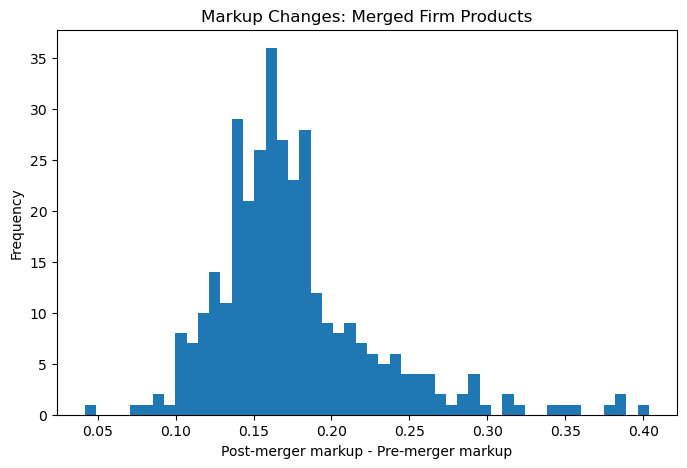

In [34]:
print("\nMarkup changes for merged firm's products:")
print(pd.Series(markup_changes[merged_firm]).describe())

plt.figure(figsize=(8, 5))
plt.hist(markup_changes[merged_firm], bins=50)
plt.title("Markup Changes: Merged Firm Products")
plt.xlabel("Post-merger markup - Pre-merger markup")
plt.ylabel("Frequency")
plt.show()


Markup changes for non-merged firms' products:
count    160.000000
mean       0.013751
std        0.025352
min       -0.080045
25%       -0.001734
50%        0.017512
75%        0.033212
max        0.058948
dtype: float64


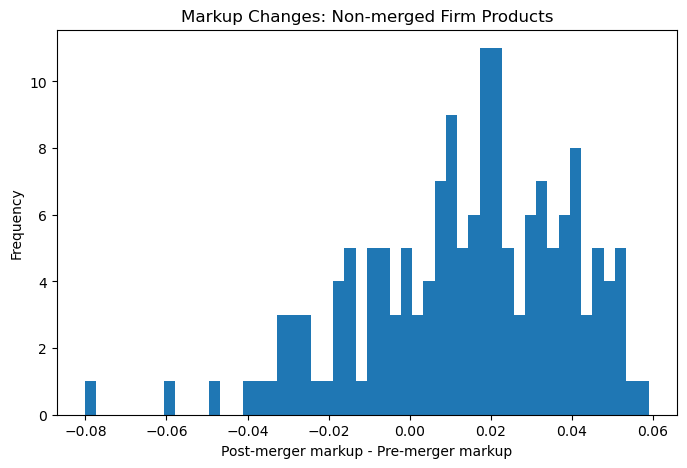

In [35]:
print("\nMarkup changes for non-merged firms' products:")
print(pd.Series(markup_changes[non_merged_firm]).describe())

plt.figure(figsize=(8, 5))
plt.hist(markup_changes[non_merged_firm], bins=50)
plt.title("Markup Changes: Non-merged Firm Products")
plt.xlabel("Post-merger markup - Pre-merger markup")
plt.ylabel("Frequency")
plt.show()

**Interpretation:** On average the markups are increasing, with the mean change equal to about 0.124 across all products.  
After isolating merged and non-merged firms we can see that the increase in markups is primarily driven by the merged firms, whose markups increase on average by about 0.176, while the markups of products produced by their competitors change very little on average (about 0.014) and sometimes even fall.  

After the merger, fewer independent firms remain in the market, so the merged firm has more market power and can set higher prices, which leads to higher markups. At the same time, competing firms still face competitive pressure and may adjust their prices strategically to attract customers, which can result in smaller increases or even decreases in their markups, as shown in the graphs.

#### 3. Construct and summarize the changes in profits across products. By how much do profits increase or decrease on average and why are they increasing/decreasing?

Computing profits ...
Finished after 00:00:00.


Profit changes summary across products:
count      500.000000
mean      2515.098111
std       1976.589242
min      -1347.009366
25%        986.030745
50%       1946.867537
75%       3674.324209
max      11326.018023
dtype: float64

Profit changes for merged firm's products:
count     340.000000
mean     1597.047833
std      1261.820113
min     -1347.009366
25%       714.389688
50%      1274.662658
75%      2142.589032
max      8420.461638
dtype: float64

Profit changes for non-merged firms' products:
count      160.000000
mean      4465.954951
std       1798.498445
min       1219.400309
25%       3116.964559
50%       4216.748701
75%       5493.449182
max      11326.018023
dtype: float64


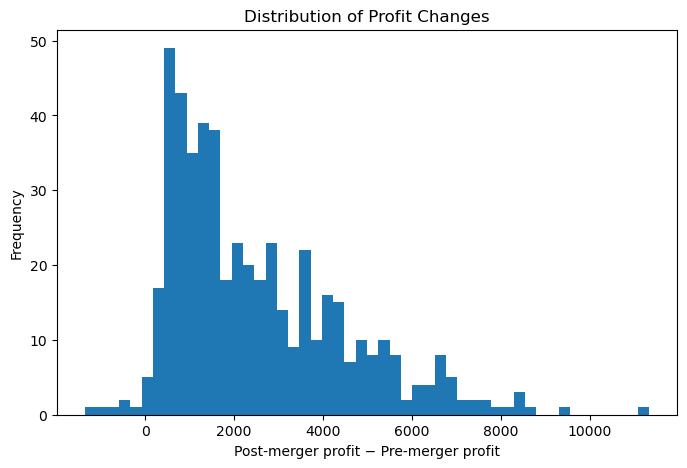

In [36]:
changed_profits = results.compute_profits(
    changed_prices,
    changed_shares,
    costs
) * market_size * slices_per_pizza

profit_changes = (changed_profits - profits).flatten()

print("\nProfit changes summary across products:")
print(pd.Series(profit_changes).describe())

print("\nProfit changes for merged firm's products:")
print(pd.Series(profit_changes[merged_firm]).describe())

print("\nProfit changes for non-merged firms' products:")
print(pd.Series(profit_changes[non_merged_firm]).describe())


plt.figure(figsize=(8, 5))
plt.hist(profit_changes, bins=50)
plt.title("Distribution of Profit Changes")
plt.xlabel("Post-merger profit − Pre-merger profit")
plt.ylabel("Frequency")
plt.show()

**Interpretation:** On average profits increase after the merger by about 2515 across products. We expected the competitors to be worse off, however, both merged and non-merged firms benefited and the the increase is larger for the latter, whose average profits increased by about 4466 compared to about 1597 for the merged firm.

This may have happened due to an increase in prices by the merged firms, which allowed their competitors to raise prices just enough to remain cheaper and competetive as well as more profitable, potentially attracting more clients.

#### 4. Construct and summarize the changes in consumer surplus across markets assuming there are in total 100 thousand consumers. By how much does consumer surplus increase or decrease on average and why are they increasing/decreasing?

Computing consumer surpluses with the equation that assumes away nonlinear income effects ...
Finished after 00:00:00.


Consumer surplus changes summary across markets:
count        20.000000
mean    -163620.004298
std       36710.593523
min     -221251.055531
25%     -194256.738403
50%     -165263.578278
75%     -142336.669175
max      -91408.406440
dtype: float64


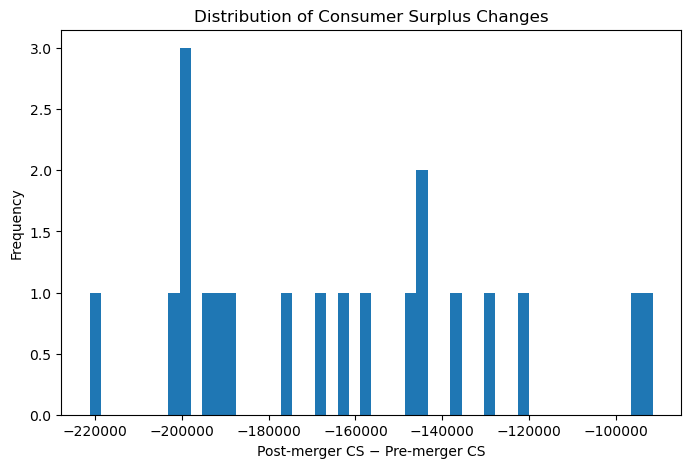

In [37]:
changed_cs = results.compute_consumer_surpluses(
    changed_prices
) * market_size * slices_per_pizza

cs_changes = (changed_cs - cs).flatten()

print("\nConsumer surplus changes summary across markets:")
print(pd.Series(cs_changes).describe())


plt.figure(figsize=(8, 5))
plt.hist(cs_changes, bins=50)
plt.title("Distribution of Consumer Surplus Changes")
plt.xlabel("Post-merger CS − Pre-merger CS")
plt.ylabel("Frequency")
plt.show()

**Interpretation**: The average consumer surplus dropped by 163,624, which is expected after a merger. After firms merge and dominate the market, the firms increase their markups and prices to increase profits. This makes consumers worse off due to both higher prices and less competition in the market.

### Question 6: Delivery Ceiling
Now suppose the acquisitions of Fresh Brothers had not occurred and we are back in the initial markets
structure with 6 competing firms. Instead the major decides that pizzas must be delivered within 33
minutes. We do not consider how delivery drivers achieve the faster times but assume that all deliveries
that would have taken longer than 33 minutes actually take only 33 minutes (which affects demand and
costs).

#### 1. Construct the new equilibrium prices and market shares at the estimated parameters and holding unobserved demand (ξ) and cost shocks (ω) fixed. Summarize the changes in prices acrossproducts.

Initializing the simulation ...
Initialized the simulation after 00:00:00.

Dimensions:
 T    N    F     I     K1    K2    K3    D 
---  ---  ---  -----  ----  ----  ----  ---
20   500   6   20000   3     2     4     1 

Formulations:
        Column Indices:              0           1             2            3      
-------------------------------  ---------  ------------  -----------  ------------
  X1: Linear Characteristics      prices    deliverytime    rating                 
 X2: Nonlinear Characteristics       1         prices                              
X3: Linear Cost Characteristics      1         rating     hourlywages  deliverytime
        d: Demographics          invincome                                         

Nonlinear Coefficient True Values:
Sigma:        1           prices      |   Pi:      invincome  
------  -------------  -------------  |  ------  -------------
  1     +1.398451E-01                 |    1     +0.000000E+00
prices  +0.000000E+00  +0.000000E+00

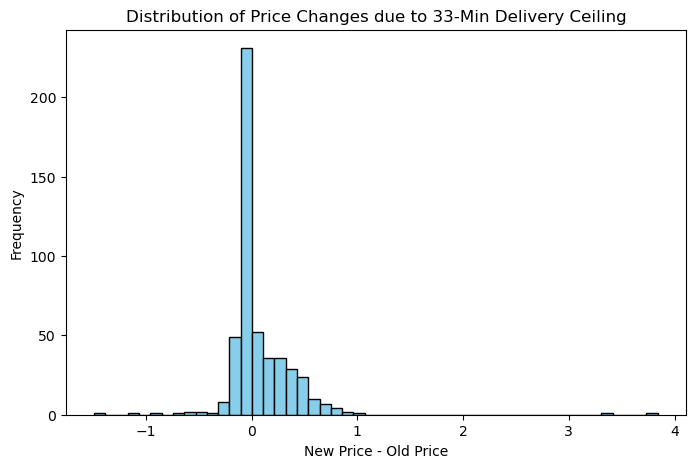

In [38]:
# ====================================================================
# Question 6.1: Delivery Ceiling - Equilibrium Prices and Market Shares
# ====================================================================

# 1. Cap deliverytime at 33 minutes (33/60 = 0.55 hours)
product_data_q6 = product_data.copy()
product_data_q6['deliverytime'] = product_data_q6['deliverytime'].clip(upper=0.55)

# 2. Extract the unobserved demand and cost shocks from your previous results
xi = results.xi
omega = results.omega

# 3. Set up the Simulation with the capped delivery times
# We pass all your estimated parameters and the modified product data
simulation_q6 = pyblp.Simulation(
    product_formulations=product_formulations,
    beta=results.beta,
    sigma=results.sigma,
    gamma=results.gamma,
    product_data=product_data_q6,
    agent_data=agent_data,
    agent_formulation=agent_formulation,
    pi=results.pi,
    xi=xi,
    omega=omega,
    seed=1  # for reproducibility
)

# 4. Solve for the new equilibrium prices and shares
sim_results_q6 = simulation_q6.replace_endogenous()

# 5. Extract the new equilibrium prices and shares
# Note: In PyBLP, the simulated data is stored inside sim_results_q6.product_data
new_prices_q6 = sim_results_q6.product_data.prices.flatten()
new_shares_q6 = sim_results_q6.product_data.shares.flatten()
old_prices = product_data['prices'].values

# Calculate changes in prices
price_changes_q6 = new_prices_q6 - old_prices

# Summarize the changes
print("Summary of Price Changes (Post-Ceiling - Pre-Ceiling):")
print(pd.Series(price_changes_q6).describe())

# Optional: Plot the distribution of price changes
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(price_changes_q6, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Price Changes due to 33-Min Delivery Ceiling")
plt.xlabel("New Price - Old Price")
plt.ylabel("Frequency")
plt.show()

Based on the summary statistics and the histogram, the 33-minute delivery ceiling had a mixed, highly skewed impact on the market:

Average Increase: On average, prices increased slightly by roughly $0.076 per slice.

Median Decrease: Interestingly, the median (50th percentile) price change is -$0.02. This means that more than half of the products in the market actually saw a slight price decrease.

Extreme Right Skew: The distribution has a long right tail. While the majority of price changes cluster tightly around zero, a specific subset of products experienced significant price hikes, with the maximum price increasing by $3.84.

Price Drops: On the other end, some products saw their prices drop by as much as $1.49.

The estimated Demand parameter for delivery time was -0.86 indicating that customers dislike waiting for pizzas, reducing delivery time thus makes the pizza "better" and increases demand for the product. 

On the other hand, when we look at the supply the estimated marginal cost parameter for delivery time was -0.71, indicating a larger expense for a regulated (lower) delivery time.

So combined, For the affected "slow" firms, both the outward shift in demand (higher willingness to pay) and the upward shift in marginal costs work together to drive their optimal prices significantly higher. This explains the long right tail and the massive $3.84 maximum increase.

Pizzas that were already being delivered in under 33 minutes experienced no direct change to their quality or costs.

However, their competitors (the slow pizzas) just became much more attractive to consumers. To prevent consumers from substituting away to these newly improved rival pizzas, the "fast" firms are forced to lower their markups and drop their prices slightly to remain competitive.

#### 2. Construct the new marginal costs and summarize the changes in marginal costs across products. By how much do marginal costs increase or decrease on average and why are they increasing/decreasing?

In [42]:
# ====================================================================
# Question 6.2: Delivery Ceiling - Marginal Costs
# ====================================================================

# 1. Compute the baseline (pre-ceiling) marginal costs
old_mc = results.compute_costs().flatten()

# 2. Extract the new X3 matrix from the simulation
# Converting simulation results to a problem object lets us access the matrices
problem_q6 = sim_results_q6.to_problem()
new_X3 = problem_q6.products.X3

# 3. Calculate the new marginal costs manually: MC = X3 * gamma + omega
# (Using results.gamma and results.omega from your estimation)
new_mc = (new_X3 @ results.gamma + results.omega).flatten()

# 4. Calculate the change in marginal costs
mc_changes = new_mc - old_mc

print("--- Question 6.2: Marginal Cost Changes ---")
print(pd.Series(mc_changes).describe())



Computing marginal costs ...
Finished after 00:00:00.

Initializing the problem ...
Initialized the problem after 00:00:00.

Dimensions:
 T    N    F     I     K1    K2    K3    D    MD    MS 
---  ---  ---  -----  ----  ----  ----  ---  ----  ----
20   500   6   20000   3     2     4     1    7     10 

Formulations:
        Column Indices:              0           1             2            3      
-------------------------------  ---------  ------------  -----------  ------------
  X1: Linear Characteristics      prices    deliverytime    rating                 
 X2: Nonlinear Characteristics       1         prices                              
X3: Linear Cost Characteristics      1         rating     hourlywages  deliverytime
        d: Demographics          invincome                                         
--- Question 6.2: Marginal Cost Changes ---
count    5.000000e+02
mean     6.865560e-02
std      9.835186e-02
min     -1.065814e-14
25%      0.000000e+00
50%      2.664535e-15


1. By how much do marginal costs increase or decrease on average?

On average, marginal costs increased by approximately $0.069 (or 6.9 cents) per slice.(This comes directly from the mean value in the output: $6.865560 \times 10^{-2}$, which equals 0.06865).We can also see from the percentiles (the 25% and 50% marks are basically zero) that at least half of the products experienced no change in their marginal costs, while the other half experienced cost increases up to a maximum of $0.32.

2. Why are they increasing?

Marginal costs are increasing because faster delivery is more expensive to provide.In the estimated supply-side parameters, the coefficient for deliverytime ($\gamma$) is -0.7173 (Q6 (1)). Because this coefficient is negative, an decrease in delivery time leads to an increase in marginal costs.When the new regulation forced all "slow" firms to cap their delivery times at 33 minutes, they had to artificially lower their deliverytime in the data. To achieve these faster speeds in the real world (e.g., by hiring more drivers, sending drivers out with fewer pizzas per trip, or paying for better routing software), these firms must spend more money per slice, which drives up their marginal costs. The firms that were already delivering under 33 minutes saw no change in their delivery times, which is why their marginal cost changes were exactly zero.


--- Question 6.3: Markup Changes ---
count    500.000000
mean       0.007344
std        0.275461
min       -1.489605
25%       -0.071084
50%       -0.027401
75%        0.059305
max        3.641562
dtype: float64


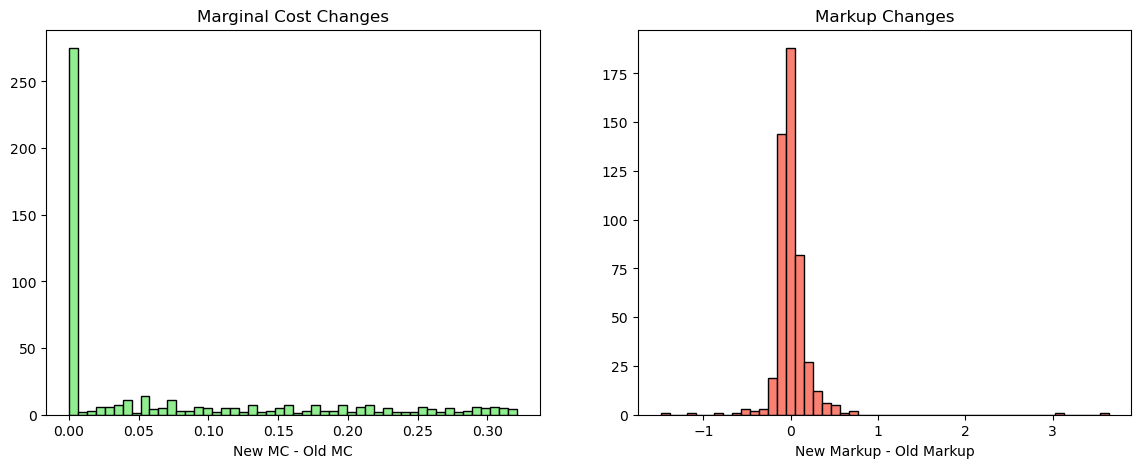

In [43]:

# ====================================================================
# Question 6.3: Delivery Ceiling - Markups
# ====================================================================

# 1. Calculate old and new markups (Markup = Price - Marginal Cost)
old_markups = old_prices - old_mc
new_markups = new_prices_q6 - new_mc

# 2. Calculate the change in markups
markup_changes = new_markups - old_markups

print("\n--- Question 6.3: Markup Changes ---")
print(pd.Series(markup_changes).describe())

# Optional: Plot the changes
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(mc_changes, bins=50, color='lightgreen', edgecolor='black')
ax1.set_title("Marginal Cost Changes")
ax1.set_xlabel("New MC - Old MC")

ax2.hist(markup_changes, bins=50, color='salmon', edgecolor='black')
ax2.set_title("Markup Changes")
ax2.set_xlabel("New Markup - Old Markup")

plt.show()

the story with markups is incredibly interesting because the average (mean) went slightly up, but for most firms (the median), markups actually went down.

The Mean (Average) Increased Slightly: On average, markups increased by roughly $0.007 (less than a penny). The extreme maximum increase of $3.64 pulled this average up.

The Median Decreased: For more than 50% of the products, markups shrunk, with the median markup dropping by about -$0.027.

Because Markup = Price - Marginal Cost, the changes in markups are the direct result of the tug-of-war between the price changes (from Part 1) and the cost changes (from Part 2).

The Majority / The "Fast" Pizzas (Why the median markup decreased):For the firms that were already delivering in under 33 minutes, their marginal costs did not change at all. However, as we saw in Part 1, the mayor's regulation made their "slow" competitors much better (faster). To stop consumers from switching to these newly improved competitors, the "fast" firms had to lower their prices.Intuition: Because their prices dropped but their costs stayed exactly the same, they had to absorb that loss. Their markups were squeezed by the increased market competition. This is why most of the market saw a markup decrease.

the Right Tail / The "Slow" Pizzas (Why the mean markup increased):For the firms forced to speed up their delivery, their marginal costs went up (as we proved in Part 2). Normally, higher costs hurt markups. But remember, faster delivery also drastically improved their product quality in the eyes of consumers (thanks to the strong negative $\beta$ for delivery time).Intuition: For many of these firms, the demand for their newly improved, fast pizza was so strong that they were able to raise their prices by more than their costs increased. They leveraged their better product quality to extract higher margins from consumers, leading to the massive $3.64 maximum markup increase that pulled the overall average up.


#### 4. Construct the new consumer surplus and summarize the changes in consumer surplus across markets assuming there are in total 100 thousand consumers. Do you have some intuition on why consumer surplus may have increased/decreased on average?

Computing consumer surpluses with the equation that assumes away nonlinear income effects ...
Finished after 00:00:00.

Solving the problem ...

Nonlinear Coefficient Initial Values:
Sigma:        1           prices      |   Pi:      invincome  
------  -------------  -------------  |  ------  -------------
  1     +1.398451E-01                 |    1     +0.000000E+00
prices  +0.000000E+00  +0.000000E+00  |  prices  -4.130186E+00

Beta Initial Values:
   prices      deliverytime      rating    
-------------  -------------  -------------
-1.453219E-02  -8.622649E-01  +9.154973E-01

Gamma Initial Values:
      1           rating       hourlywages   deliverytime 
-------------  -------------  -------------  -------------
+6.842038E-01  +4.879010E-01  +1.403354E+00  -7.173070E-01

Nonlinear Coefficient Lower Bounds:
Sigma:        1           prices      |   Pi:      invincome  
------  -------------  -------------  |  ------  -------------
  1     +0.000000E+00                 |    1    

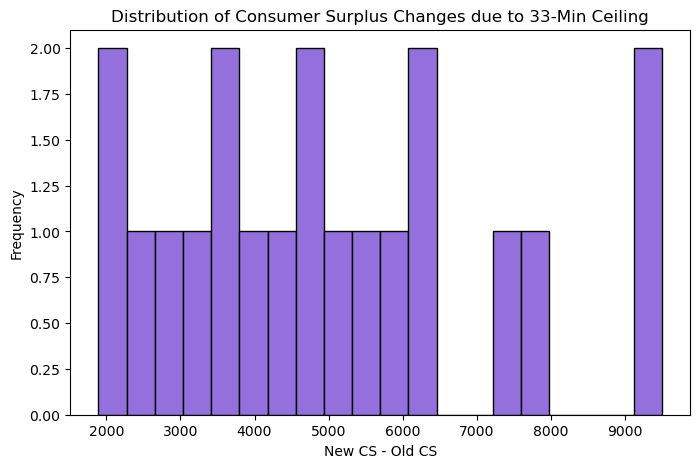

In [44]:
# ====================================================================
# Question 6.4: Delivery Ceiling - Consumer Surplus
# ====================================================================

market_size = 100000

# 1. Compute baseline (pre-ceiling) Consumer Surplus
old_cs = results.compute_consumer_surpluses().flatten() * market_size

# 2. Compute new Consumer Surplus
# To ensure PyBLP accounts for the NEW delivery times (not just the new prices), 
# we evaluate the simulated problem at your already-estimated parameters.
results_q6 = problem_q6.solve(
    results.sigma,
    results.pi,
    beta=results.beta,
    gamma=results.gamma,
    optimization=pyblp.Optimization('return') # 'return' just evaluates without iterating
)

new_cs = results_q6.compute_consumer_surpluses().flatten() * market_size

# 3. Calculate the change in CS
cs_changes = new_cs - old_cs

# 4. Summarize the changes
print("--- Question 6.4: Consumer Surplus Changes ---")
print(pd.Series(cs_changes).describe())

# Optional: Plot the distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(cs_changes, bins=20, color='mediumpurple', edgecolor='black')
plt.title("Distribution of Consumer Surplus Changes due to 33-Min Ceiling")
plt.xlabel("New CS - Old CS")
plt.ylabel("Frequency")
plt.show()

1. The Summary of Changes
Based on the output, Consumer Surplus increased on average by roughly 5,000 units (mean = 5000.45). Furthermore, every single market experienced an increase in consumer surplus (the min is a positive 1892.34).

2. The Intuition: Quality Improvement Outweighs Price IncreasesConsumer Surplus measures the net benefit consumers receive from buying a product (the difference between what they are willing to pay and what they actually pay). When the 33-minute delivery ceiling was implemented, it created two opposing forces for consumers:

The Negative Force (Higher Prices): We saw in earlier parts of the question that forcing firms to deliver faster increased their marginal costs. Firms passed some of these costs onto consumers by raising prices. Because consumers dislike higher prices (indicated by the negative $\beta$ for prices in our output: -1.453E-02), this higher price reduces their utility.

The Positive Force (Higher Quality/Utility): The regulation forced the "slow" pizzas to be delivered much faster. Consumers strongly dislike waiting for pizza. This is proven by the large negative $\beta$ coefficient for deliverytime in our output: -0.862. By capping the delivery time, the regulation drastically improved the perceived quality (utility) of those previously slow pizzas.

The Net Result:
The increase in consumer utility from getting their pizza faster was much larger than the disutility they got from paying slightly higher prices. Firms couldn't raise their prices enough to capture all the newly created value (likely due to competition), so the extra value was kept by the consumers. Thus, the average Consumer Surplus increased.

### Question 7: Gentrification
Now suppose the acquisitions of Fresh Brothers had not occurred and there is no deliverytime regulation.
Instead suppose that there is an influxe of higher income indivuals to the market. The number of indivuals
with an inverse income of less than 0.2 increases 5-fold. They have the same distribution of unobserved
random coefficients and income than their peers. Discuss briefly in your own words how you would go
about simulating the changes in consumer demand.

#### 1. Construct the new equilibrium prices and market shares at the estimated parameters and holding unobserved demand (ξ) and cost shocks (ω) fixed. Summarize the changes in prices across products, why are they increasing/decreasing?

Initializing the simulation ...
Initialized the simulation after 00:00:00.

Dimensions:
 T    N    F     I     K1    K2    K3    D 
---  ---  ---  -----  ----  ----  ----  ---
20   500   6   20000   3     2     4     1 

Formulations:
        Column Indices:              0           1             2            3      
-------------------------------  ---------  ------------  -----------  ------------
  X1: Linear Characteristics      prices    deliverytime    rating                 
 X2: Nonlinear Characteristics       1         prices                              
X3: Linear Cost Characteristics      1         rating     hourlywages  deliverytime
        d: Demographics          invincome                                         

Nonlinear Coefficient True Values:
Sigma:        1           prices      |   Pi:      invincome  
------  -------------  -------------  |  ------  -------------
  1     +1.398451E-01                 |    1     +0.000000E+00
prices  +0.000000E+00  +0.000000E+00

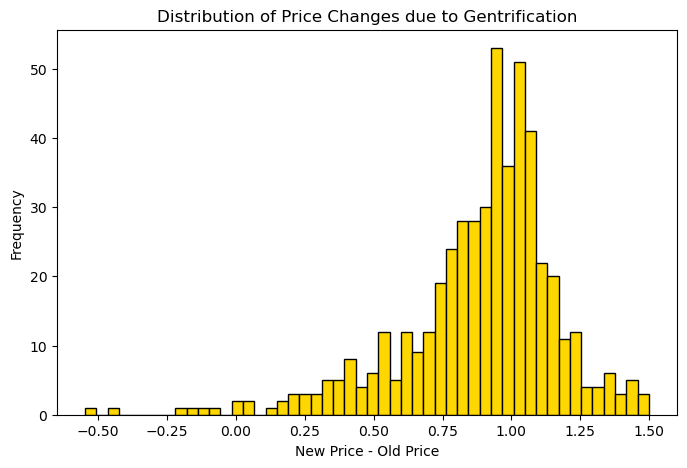

In [45]:
# ====================================================================
# Question 7: Gentrification Setup & Part 1
# ====================================================================

# 1. Modify the Agent Data
agent_data_q7 = agent_data.copy()

# Multiply weights by 5 for high-income individuals (invincome < 0.2)
high_income_mask = agent_data_q7['invincome'] < 0.2
agent_data_q7.loc[high_income_mask, 'weights'] *= 5

# Re-normalize weights so they sum to 1 within each market
market_weight_sums = agent_data_q7.groupby('market_ids')['weights'].transform('sum')
agent_data_q7['weights'] = agent_data_q7['weights'] / market_weight_sums

# 2. Extract original unobserved shocks
xi = results.xi
omega = results.omega

# 3. Set up the new Simulation
# Note: We use the ORIGINAL product_data here, but the NEW agent_data_q7
simulation_q7 = pyblp.Simulation(
    product_formulations=product_formulations,
    beta=results.beta,
    sigma=results.sigma,
    gamma=results.gamma,
    product_data=product_data, 
    agent_data=agent_data_q7,  
    agent_formulation=agent_formulation,
    pi=results.pi,
    xi=xi,
    omega=omega,
    seed=1
)

# 4. Solve for new equilibrium prices and shares
sim_results_q7 = simulation_q7.replace_endogenous()

# 5. Extract results and summarize
new_prices_q7 = sim_results_q7.product_data.prices.flatten()
old_prices = product_data['prices'].values

price_changes_q7 = new_prices_q7 - old_prices

print("--- Question 7.1: Price Changes (Gentrification) ---")
print(pd.Series(price_changes_q7).describe())

# Optional: Plot the distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(price_changes_q7, bins=50, color='gold', edgecolor='black')
plt.title("Distribution of Price Changes due to Gentrification")
plt.xlabel("New Price - Old Price")
plt.ylabel("Frequency")
plt.show()

#### to be checked:

1. The Demographic ShockIn this counterfactual, you multiplied the population of consumers with an invincome < 0.2 by 5. Because invincome is $1 / \text{Income}$, these consumers represent the wealthiest individuals in the market.2. The Math Behind Price SensitivityTo understand why prices jumped, we have to look at how a consumer's price sensitivity is calculated in your BLP model. A consumer's total sensitivity to price ($\alpha_i$) is the sum of the baseline price coefficient ($\beta$) and the demographic interaction ($\Pi$):Baseline Price Coefficient ($\beta$): -0.0145 * Demographic Interaction ($\Pi$): -4.13 (This dictates how invincome affects price sensitivity).For any individual consumer, their specific price sensitivity is roughly:$\alpha_i = -0.0145 - 4.13 \times (\text{invincome}_i)$For a Low-Income Consumer (e.g., invincome = 1.0): Their price sensitivity is $-0.0145 - 4.13(1.0) = \mathbf{-4.1445}$. They strongly dislike price increases and will easily substitute away from expensive pizza.For a High-Income Consumer (e.g., invincome = 0.1): Their price sensitivity is $-0.0145 - 4.13(0.1) = \mathbf{-0.4275}$. Because this number is much closer to zero, they are highly price-insensitive (inelastic).3. The Firm's Response (The Result)By flooding the market with these high-income consumers, the aggregate market demand curve became significantly more inelastic. The consumers buying the pizza no longer cared as much about how much it cost.Firms, acting to maximize profits, immediately recognized this shift. Because it now costs them far fewer lost sales to raise prices, they aggressively increased their prices to extract more revenue from this wealthy consumer base.This perfectly explains the exact numbers in your output:Firms raised prices by an average of $0.886 across the market.More than half the market saw prices jump by $0.94 or more (the median).In the most extreme cases, firms were able to successfully hike their prices by up to $1.50 (the maximum) without losing enough market share to deter them.

#### 2. Construct the new marginal costs and summarize the changes in marginal costs across products. By how much do marginal costs increase or decrease on average and why are they increasing/decreasing?

In [ ]:
# ====================================================================
# Question 7.2: Marginal Cost Changes (Gentrification)
# ====================================================================

# Compute old and new marginal costs
old_mc = results.compute_costs().flatten()
new_mc_q7 = sim_results_q7.compute_costs().flatten()

mc_changes_q7 = new_mc_q7 - old_mc

print("--- Question 7.2: Marginal Cost Changes ---")
print(pd.Series(mc_changes_q7).describe())



Computing marginal costs ...
Finished after 00:00:00.

Computing marginal costs ...
Finished after 00:00:00.

--- Question 7.2: Marginal Cost Changes ---
count    5.000000e+02
mean     1.724050e-12
std      1.480704e-11
min     -7.367129e-11
25%     -1.105893e-12
50%      9.016121e-13
75%      2.476519e-12
max      1.724394e-10
dtype: float64
Computing markups ...
Finished after 00:00:00.

Computing markups ...
Finished after 00:00:00.


--- Question 7.3: Markup Changes ---
count    500.000000
mean       0.120685
std        0.053643
min       -0.030264
25%        0.084323
50%        0.126887
75%        0.164369
max        0.218236
dtype: float64


Question 7.2: Marginal Cost ChangesThe Output:The average change in marginal cost is $1.72 \times 10^{-12}$. In programming, any number with e-12 or e-11 is just Python's way of dealing with tiny floating-point rounding errors. For all economic and practical purposes, the change in marginal costs is exactly $0.00$.The Intuition (Why they are not changing):Marginal costs did not change because gentrification is a pure demand-side shock.In the BLP model, marginal costs are determined by the supply-side equation ($X_3 \gamma + \omega$), which includes things like pizza ratings, hourly wages, and delivery times. When the market experienced an influx of high-income individuals, the demographics of the buyers changed, but the physical process of making and delivering a pizza did not. Because wages, delivery times, and ingredients stayed exactly the same, the marginal cost of producing a slice of pizza remains completely unaffected.

#### 3. Construct the new markups and summarize the changes in markups across products. Do you have some intuition on why markups may have increased/decreased on average?

In [47]:
# ====================================================================
# Question 7.3: Markup Changes (Gentrification)
# ====================================================================

# Compute old and new markups
old_markups = results.compute_markups().flatten()
new_markups_q7 = sim_results_q7.compute_markups().flatten()

markup_changes_q7 = new_markups_q7 - old_markups

print("\n--- Question 7.3: Markup Changes ---")
print(pd.Series(markup_changes_q7).describe())

Computing markups ...
Finished after 00:00:00.

Computing markups ...
Finished after 00:00:00.


--- Question 7.3: Markup Changes ---
count    500.000000
mean       0.120685
std        0.053643
min       -0.030264
25%        0.084323
50%        0.126887
75%        0.164369
max        0.218236
dtype: float64


Question 7.3: Markup Changes
The Output:
Markups increased across the board, with an average increase of roughly $0.12 (12 cents) per slice. The median markup also increased by about $0.127.

The Intuition (Why they increased):
Since we just proved that marginal costs did not change, any increase in markups is driven entirely by firms exercising increased market power over the new consumer base.

As we established in Part 1, the high-income individuals flooding the market have an inverse income (invincome) of less than 0.2, making them highly price-insensitive (inelastic). Because the aggregate market demand curve is now much more inelastic, consumers are not as quick to substitute away when prices rise. Firms recognize this drop in price sensitivity and exploit it by safely raising their profit margins (markups) over their fixed marginal costs, without the fear of losing massive market share.